<a href="https://colab.research.google.com/github/anu04596/Neural-Network-and-Deep-Learning/blob/main/Project6_PracticalFile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install split-folders

In [4]:
import os
import random
import numpy as np
import pandas as pd
import splitfolders
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam

In [5]:
BASE_DIR = "/content/drive/MyDrive/PlantVillage"

potato_classes = [d for d in os.listdir(BASE_DIR) if d.startswith('Potato')]


print("Potato Classes:", potato_classes)

Potato Classes: ['Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight']


In [6]:
splitfolders.ratio(
    BASE_DIR,
    output='dataset',
    seed = 42,
    ratio = (0.8, 0.1, 0.1),
    group_prefix=None
)

Copying files: 20639 files [04:57, 69.44 files/s] 


In [7]:
IMG_SIZE = 256

BATCH_SIZE = 32


train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 10,
    horizontal_flip = True
)

val_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1./255)

In [9]:
train_generator = train_datagen.flow_from_directory(
    '/content/dataset/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size= BATCH_SIZE,
    class_mode = 'sparse',
    classes= potato_classes
)

val_generator = val_datagen.flow_from_directory(
    "/content/dataset/val",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    classes=potato_classes
)
test_generator = test_datagen.flow_from_directory(
    "/content/dataset/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    classes=potato_classes
)

Found 1721 images belonging to 3 classes.
Found 215 images belonging to 3 classes.
Found 216 images belonging to 3 classes.


In [10]:
class_names = list(train_generator.class_indices.keys())

print(class_names)

['Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight']


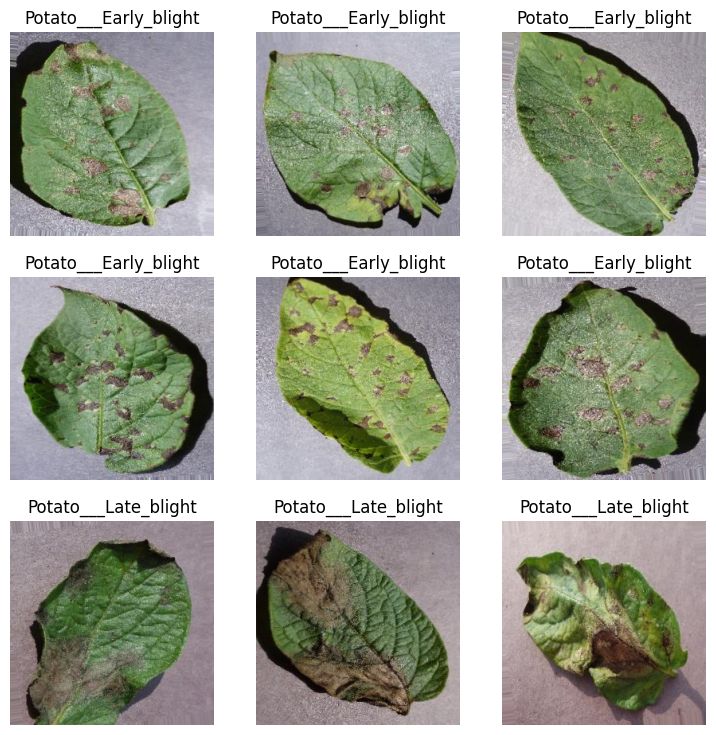

In [11]:
plt.figure(figsize=(9, 9))

for images, labels in train_generator:
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
    break

plt.show()

In [17]:

model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(len(class_names), activation="softmax")
])


In [18]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [19]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 316s 6s/step - accuracy: 0.7263 - loss: 0.6401 - val_accuracy: 0.9070 - val_loss: 0.2023
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 313s 6s/step - accuracy: 0.8797 - loss: 0.3067 - val_accuracy: 0.9581 - val_loss: 0.1443
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 334s 6s/step - accuracy: 0.9326 - loss: 0.1759 - val_accuracy: 0.9814 - val_loss: 0.0720
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 327s 6s/step - accuracy: 0.9384 - loss: 0.1532 - val_accuracy: 0.9721 - val_loss: 0.0794
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 322s 6s/step - accuracy: 0.9634 - loss: 0.1035 - val_accuracy: 0.9349 - val_loss: 0.1771
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 317s 6s/step - accuracy: 0.9587 - loss: 0.1102 - val_accuracy: 0.9907 - val_loss: 0.0467
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 315s 6s/step - accuracy: 0.9494 - loss: 0.1428 - val_accuracy: 0.9395 - val_loss: 0.1571
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 312s 6s/step - accuracy: 0.9465 - loss: 0.1522 - val_accuracy: 0.9535 - v

In [20]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8611 - loss: 0.3463
Test Accuracy: 86.11%


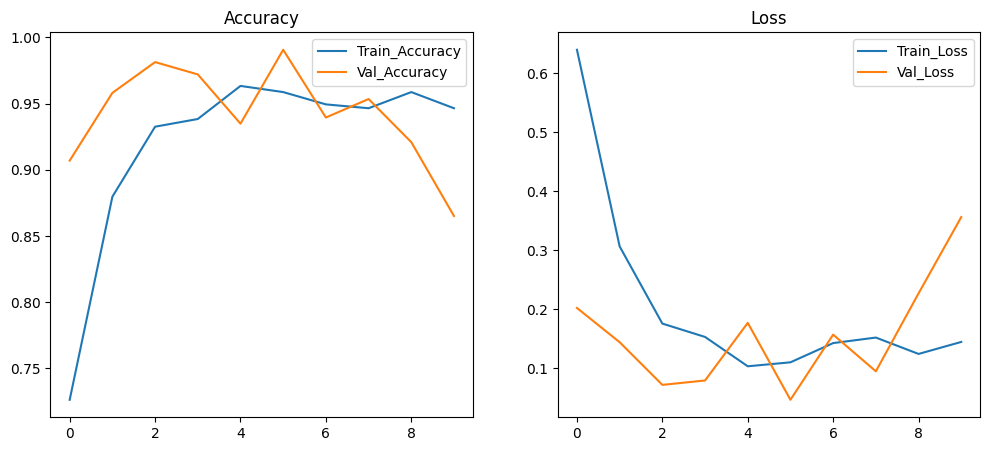

In [21]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, label = 'Train_Accuracy')
plt.plot(val_acc, label = 'Val_Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label = 'Train_Loss')
plt.plot(val_loss, label = 'Val_Loss')
plt.title('Loss')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


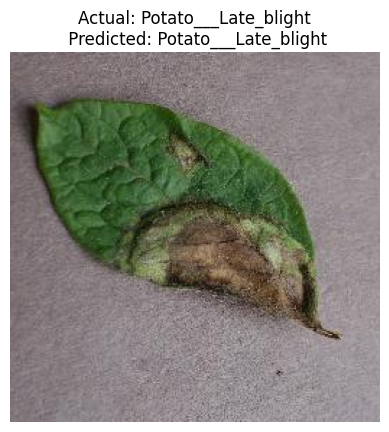

In [22]:
for images, labels in test_generator:
    img = images[0]

    # True label
    true_index = int(labels[0])
    true_label = class_names[true_index]

    # Prediction label
    predictions = model.predict(np.expand_dims(img, axis= 0))
    pred_label = class_names[np.argmax(predictions)]

    plt.imshow(img)
    plt.title(f'Actual: {true_label}\n Predicted: {pred_label}')
    plt.axis('off')
    break